# 📊 Statistics & Probability Analysis — Supermarket Sales Dataset

This notebook provides a complete walkthrough of **descriptive statistics** and **probability theory** using a real-world supermarket sales dataset.

## Dataset Overview
The dataset contains **1,000 transactions** from a supermarket chain across 3 branches (A, B, C) with columns including:
- `Unit price`, `Quantity`, `Total`, `Tax 5%`, `cogs`, `gross income`
- `Rating`, `Product line`, `Payment`, `Gender`, `Customer type`

## Topics Covered
1. **Descriptive Statistics** — Mean, Median, Mode, Variance, Std Dev, Skewness, Kurtosis
2. **Distributions** — Visualising data distributions and the Central Limit Theorem
3. **Probability Rules** — Addition, Multiplication, Conditional Probability
4. **Probability Distributions** — Normal, Binomial, Poisson

---

## 🔧 Setup: Importing Libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import norm, binom, poisson, skew, kurtosis

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14

print('😃 Libraries imported successfully!')

😃 Libraries imported successfully!


## 📂 Loading the Dataset

In [4]:
df = pd.read_csv('supermarket_sales.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (1000, 17)
Columns: ['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date', 'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income', 'Rating']


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [5]:
# Quick overview of numeric columns
df.describe().round(2)

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,55.67,5.51,15.38,322.97,307.59,4.76,15.38,6.97
std,26.49,2.92,11.71,245.89,234.18,0.00,11.71,1.72
min,10.08,1.00,0.51,10.68,10.17,4.76,0.51,4.00
25%,32.88,3.00,5.92,124.42,118.50,4.76,5.92,5.50
50%,55.23,5.00,12.09,253.85,241.76,4.76,12.09,7.00
75%,77.94,8.00,22.45,471.35,448.90,4.76,22.45,8.50
max,99.96,10.00,49.65,1042.65,993.00,4.76,49.65,10.00


---
# 📐 Part 1: Descriptive Statistics

Descriptive statistics **summarise** the main features of a dataset. Instead of looking at all 1,000 rows, we reduce data to a handful of meaningful numbers.

We'll use **`Total` (transaction amount)** as our primary variable throughout this section.

## 1.1 Measures of Central Tendency

These answer: *"Where is the centre of my data?"*

| Measure | Definition | Sensitive to Outliers? |
|---------|-----------|------------------------|
| **Mean** | Arithmetic average | ✅ Yes |
| **Median** | Middle value (50th percentile) | ❌ No |
| **Mode** | Most frequently occurring value | ❌ No |

In [6]:
# 1) Lets focus on sales

sales = df['Total']

mean_val   = sales.mean()
median_val = sales.median()
mode_val   = sales.mode()[0]   # mode() returns a Series; take the first value

print('=== Measures of Central Tendency: Total Sales ===')
print(f'  Mean   : ${mean_val:,.2f}')
print(f'  Median : ${median_val:,.2f}')
print(f'  Mode   : ${mode_val:,.2f}')
print()
print('💡 Mean > Median here → the distribution is slightly right-skewed')
print('   (a few very large transactions pull the mean upward).')

=== Measures of Central Tendency: Total Sales ===
  Mean   : $322.97
  Median : $253.85
  Mode   : $87.23

💡 Mean > Median here → the distribution is slightly right-skewed
   (a few very large transactions pull the mean upward).


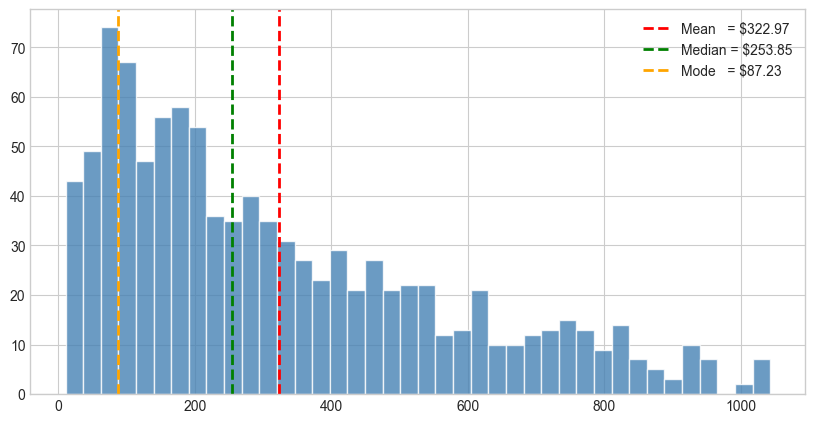

In [7]:
# 2) Lets visualize above

plt.hist(sales, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(mean_val,   color='red',    linestyle='--', linewidth=2, label=f'Mean   = ${mean_val:.2f}')
plt.axvline(median_val, color='green',  linestyle='--', linewidth=2, label=f'Median = ${median_val:.2f}')
plt.axvline(mode_val,   color='orange', linestyle='--', linewidth=2, label=f'Mode   = ${mode_val:.2f}')

plt.legend()
plt.show()

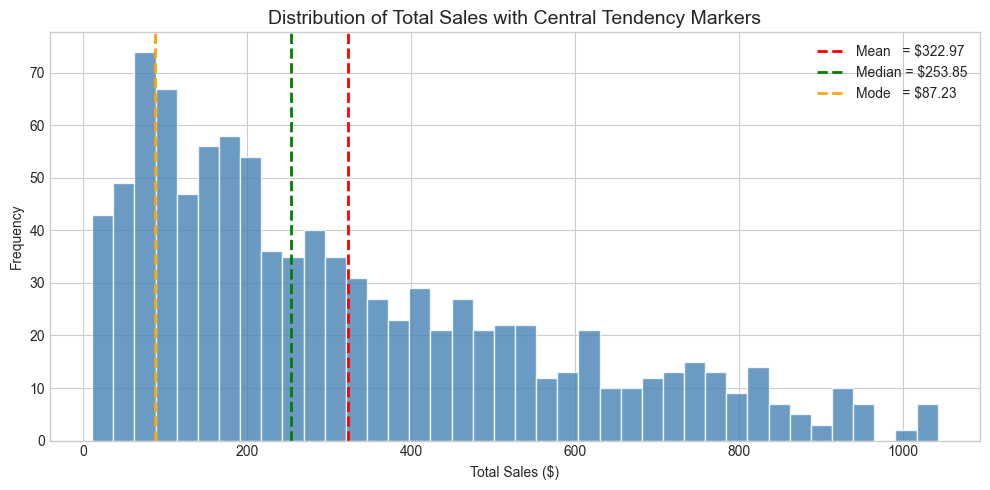

In [4]:
# 3) Prettify above

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(sales, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(mean_val,   color='red',    linestyle='--', linewidth=2, label=f'Mean   = ${mean_val:.2f}')
ax.axvline(median_val, color='green',  linestyle='--', linewidth=2, label=f'Median = ${median_val:.2f}')
ax.axvline(mode_val,   color='orange', linestyle='--', linewidth=2, label=f'Mode   = ${mode_val:.2f}')

ax.set_title('Distribution of Total Sales with Central Tendency Markers')
ax.set_xlabel('Total Sales ($)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
# The most common mode of payment

payment = df['Payment']
# print(payment.to_list())
print(payment.mode()[0])

Ewallet


In [11]:
payment.value_counts()

Payment
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


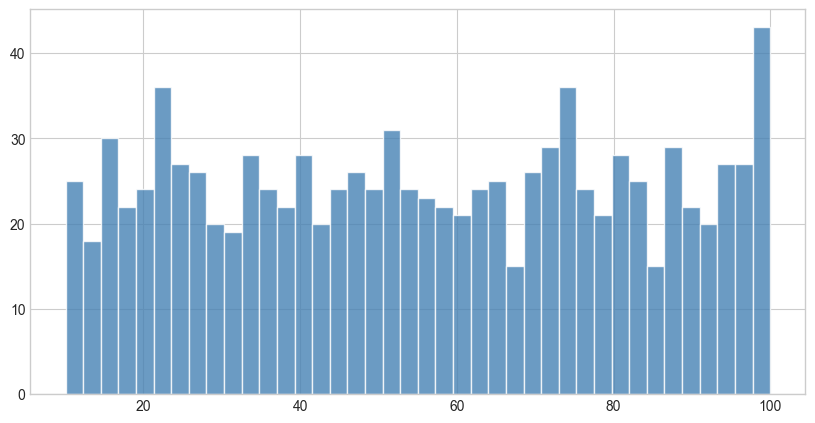

In [21]:
# Lets look at Unit Price
unit_price = df['Unit price']
plt.hist(unit_price, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
plt.legend()
plt.show()

## 1.2 Measures of Spread (Variability)

These answer: *"How spread out is my data around the centre?"*

- **Range** = max − min  
- **Variance (σ²)** = average squared deviation from the mean  
- **Standard Deviation (σ)** = square root of variance — same units as data  
- **IQR** = Q3 − Q1 (middle 50% of data)

In [14]:
range_val  = sales.max() - sales.min()
var_val    = sales.var()   # sample variance (ddof=1 by default in pandas)
std_val    = sales.std()
iqr_val    = sales.quantile(0.75) - sales.quantile(0.25)

print('=== Measures of Spread: Total Sales ===')
print(f'  Range              : ${range_val:,.2f}')
print(f'  Variance (sample)  : {var_val:,.2f}')
print(f'  Std Deviation      : ${std_val:,.2f}')
print(f'  IQR (Q3 - Q1)      : ${iqr_val:,.2f}')
print()

print("Empirical Rule:")
print(f'💡 A typical transaction (approx 68%) is within ${mean_val - std_val:.2f} – ${mean_val + std_val:.2f} (mean ± 1 std dev).')

=== Measures of Spread: Total Sales ===
  Range              : $1,031.97
  Variance (sample)  : 60,459.60
  Std Deviation      : $245.89
  IQR (Q3 - Q1)      : $346.93

Empirical Rule:
💡 A typical transaction (approx 68%) is within $77.08 – $568.85 (mean ± 1 std dev).


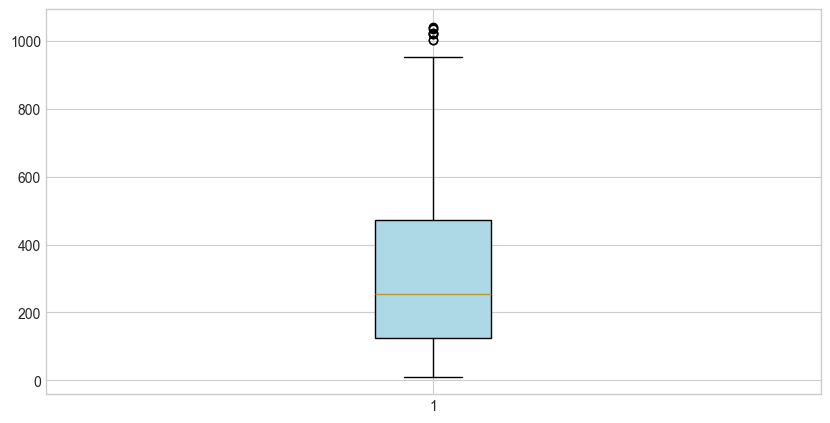

In [15]:
plt.boxplot(sales, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
plt.show()

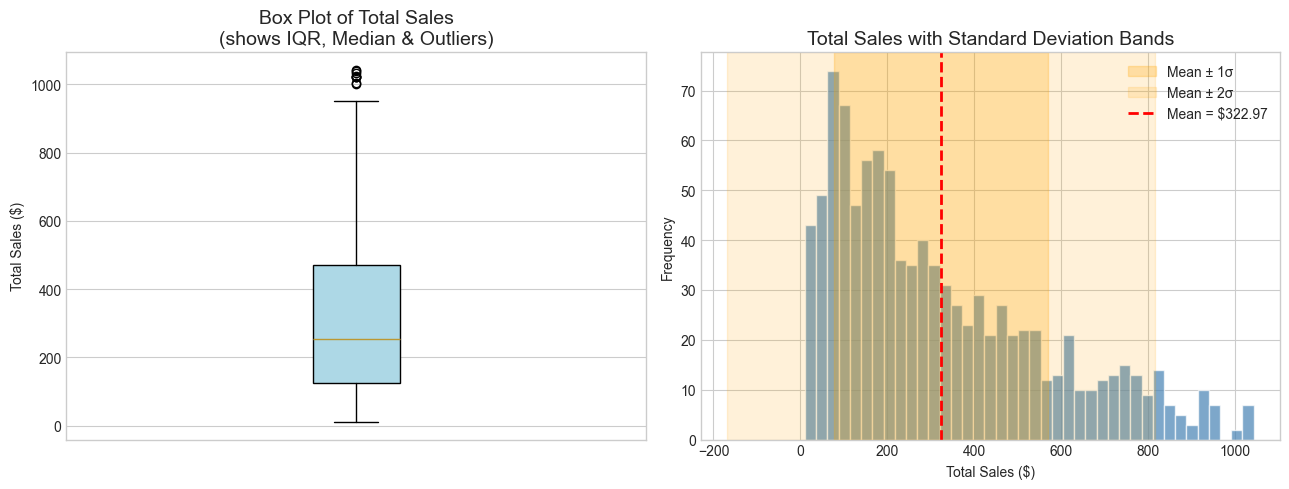

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box plot showing IQR and outliers
axes[0].boxplot(sales, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[0].set_title('Box Plot of Total Sales\n(shows IQR, Median & Outliers)')
axes[0].set_ylabel('Total Sales ($)')
axes[0].set_xticks([])

# Standard deviation bands on histogram
axes[1].hist(sales, bins=40, color='steelblue', edgecolor='white', alpha=0.7)
for i, (mult, alpha) in enumerate([(1, 0.25), (2, 0.15)]):
    axes[1].axvspan(mean_val - mult*std_val, mean_val + mult*std_val,
                    alpha=alpha, color='orange',
                    label=f'Mean ± {mult}σ')
axes[1].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = ${mean_val:.2f}')
axes[1].set_title('Total Sales with Standard Deviation Bands')
axes[1].set_xlabel('Total Sales ($)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

## 1.3 Shape of Distribution — Skewness & Kurtosis

### Skewness
Skewness measures the **asymmetry** of the distribution:
- `skewness ≈ 0` → Symmetric (normal-like)
- `skewness > 0` → **Right-skewed** (long tail on the right; mean > median)
- `skewness < 0` → **Left-skewed** (long tail on the left; mean < median)

### Kurtosis
Kurtosis measures the **heaviness of the tails** (peak sharpness):
- **Mesokurtic** (kurtosis ≈ 0 in excess): Normal distribution
- **Leptokurtic** (kurtosis > 0): Fat tails, sharp peak — more extreme outliers
- **Platykurtic** (kurtosis < 0): Thin tails, flat peak — fewer outliers

> ⚠️ SciPy's `kurtosis()` returns **excess kurtosis** (i.e., kurtosis − 3), so a normal distribution has excess kurtosis = 0.

In [19]:
numeric_cols = ['Unit price', 'Quantity', 'Total', 'gross income', 'Rating']

results = []
for col in numeric_cols:
    s = df[col].dropna()
    results.append({
        'Column'    : col,
        'Mean'      : s.mean(),
        'Median'    : s.median(),
        'Std Dev'   : s.std(),
        'Skewness'  : skew(s),
        'Ex. Kurtosis': kurtosis(s)   # excess kurtosis
    })

stats_df = pd.DataFrame(results).set_index('Column').round(4)
print('=== Shape Statistics for Key Numeric Columns ===')
stats_df

=== Shape Statistics for Key Numeric Columns ===


,Mean,Median,Std Dev,Skewness,Ex. Kurtosis
Column,,,,,
Unit price,55.6721,55.230,26.4946,0.0071,-1.2185
Quantity,5.5100,5.000,2.9234,0.0129,-1.2155
Total,322.9667,253.848,245.8853,0.8912,-0.0875
gross income,15.3794,12.088,11.7088,0.8912,-0.0875
Rating,6.9727,7.000,1.7186,0.0090,-1.1518


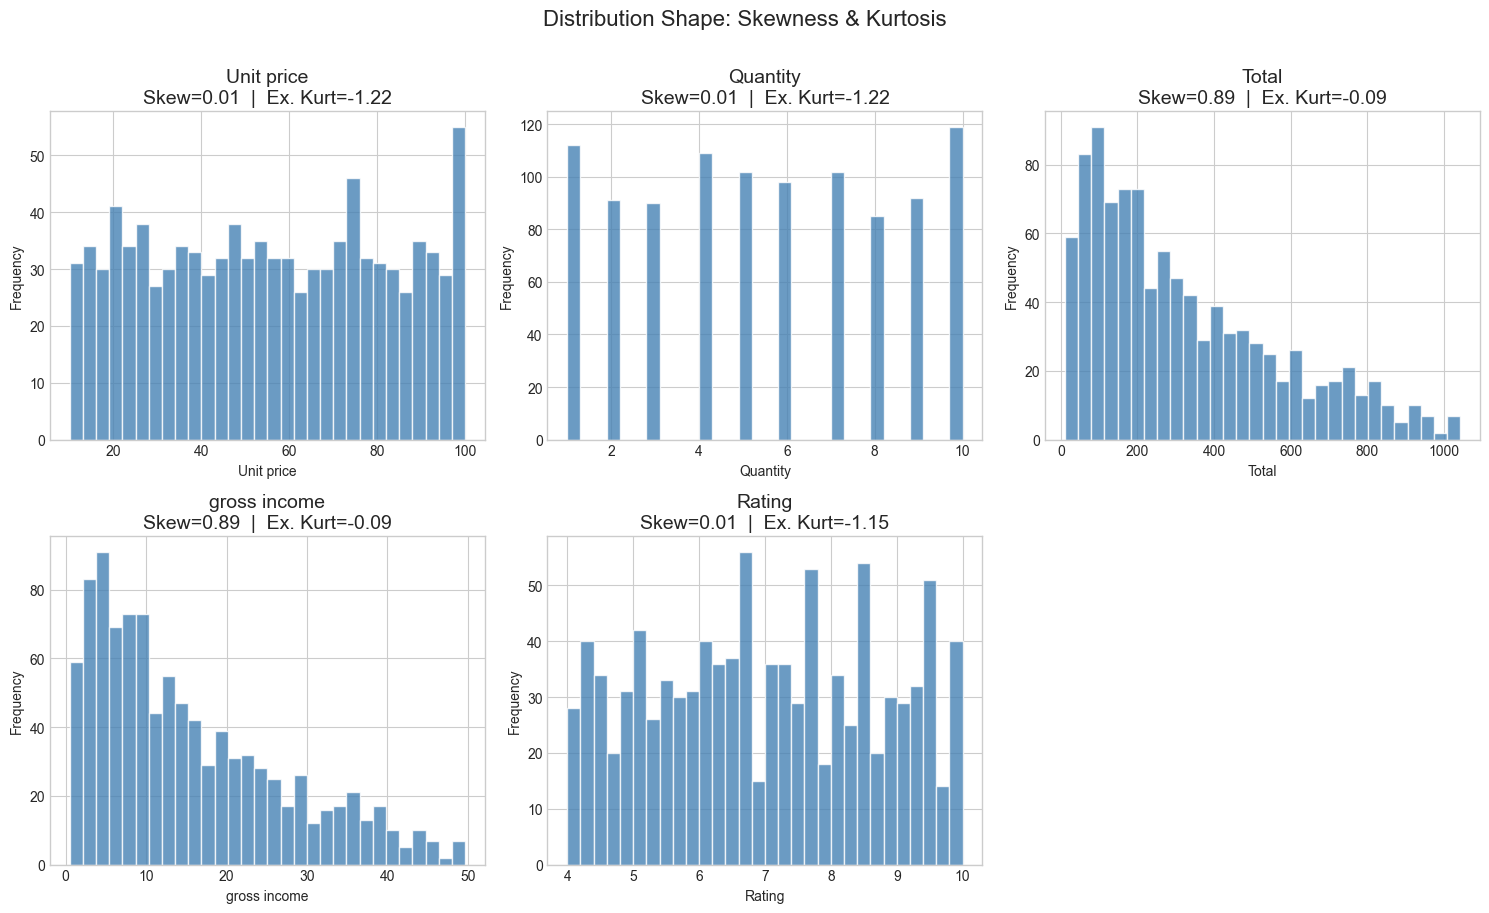

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    s = df[col].dropna()
    sk = skew(s)
    ku = kurtosis(s)
    axes[i].hist(s, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{col}\nSkew={sk:.2f}  |  Ex. Kurt={ku:.2f}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide the unused 6th subplot
axes[5].axis('off')
plt.suptitle('Distribution Shape: Skewness & Kurtosis', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

---
# 📈 Part 2: Distributions & the Central Limit Theorem

## 2.1 The Central Limit Theorem (CLT)

**The CLT states:** When you take many random samples from *any* population and compute their means, those sample means will form a **normal distribution** — regardless of the original population's shape.

- Required: sufficiently large sample size (n ≥ 30 is a common rule of thumb)
- The sampling distribution of the mean has: μ_x̄ = μ, σ_x̄ = σ/√n

Let's verify this using our `Total` sales column (which is right-skewed).

In [26]:
np.random.seed(42)
population = df['Total'].values
population

array([ 548.9715,   80.22  ,  340.5255,  489.048 ,  634.3785,  627.6165,
        433.692 ,  772.38  ,   76.146 ,  172.746 ,   60.816 ,  107.142 ,
        246.4875,  453.495 ,  749.49  ,  590.436 ,  506.6355,  457.443 ,
        172.2105,   84.63  ,  451.71  ,  277.137 ,   69.72  ,  181.44  ,
        279.1845,  441.756 ,   35.196 ,  184.107 ,  463.89  ,  235.2105,
        494.1825,  737.7615,  703.752 ,  202.818 ,  417.564 ,   71.526 ,
        328.755 ,  575.316 ,  461.328 ,  253.008 ,   91.056 ,  117.831 ,
        435.456 ,  829.08  ,   32.277 ,  394.632 ,  535.7205,  189.0945,
        119.259 ,  867.615 ,  671.79  ,  234.0975,   75.054 ,   16.2015,
         33.936 ,  722.232 ,   93.114 ,  752.64  ,  759.675 ,  192.843 ,
         77.931 ,  351.099 ,  520.4115,  166.005 ,  318.108 ,  166.635 ,
         70.287 ,  614.943 ,  827.085 ,   19.2465,  939.54  ,  652.26  ,
        152.838 ,  478.233 ,  705.6315,  437.325 ,  463.428 ,  189.0945,
        822.255 ,  106.995 ,  624.897 ,  304.542 , 

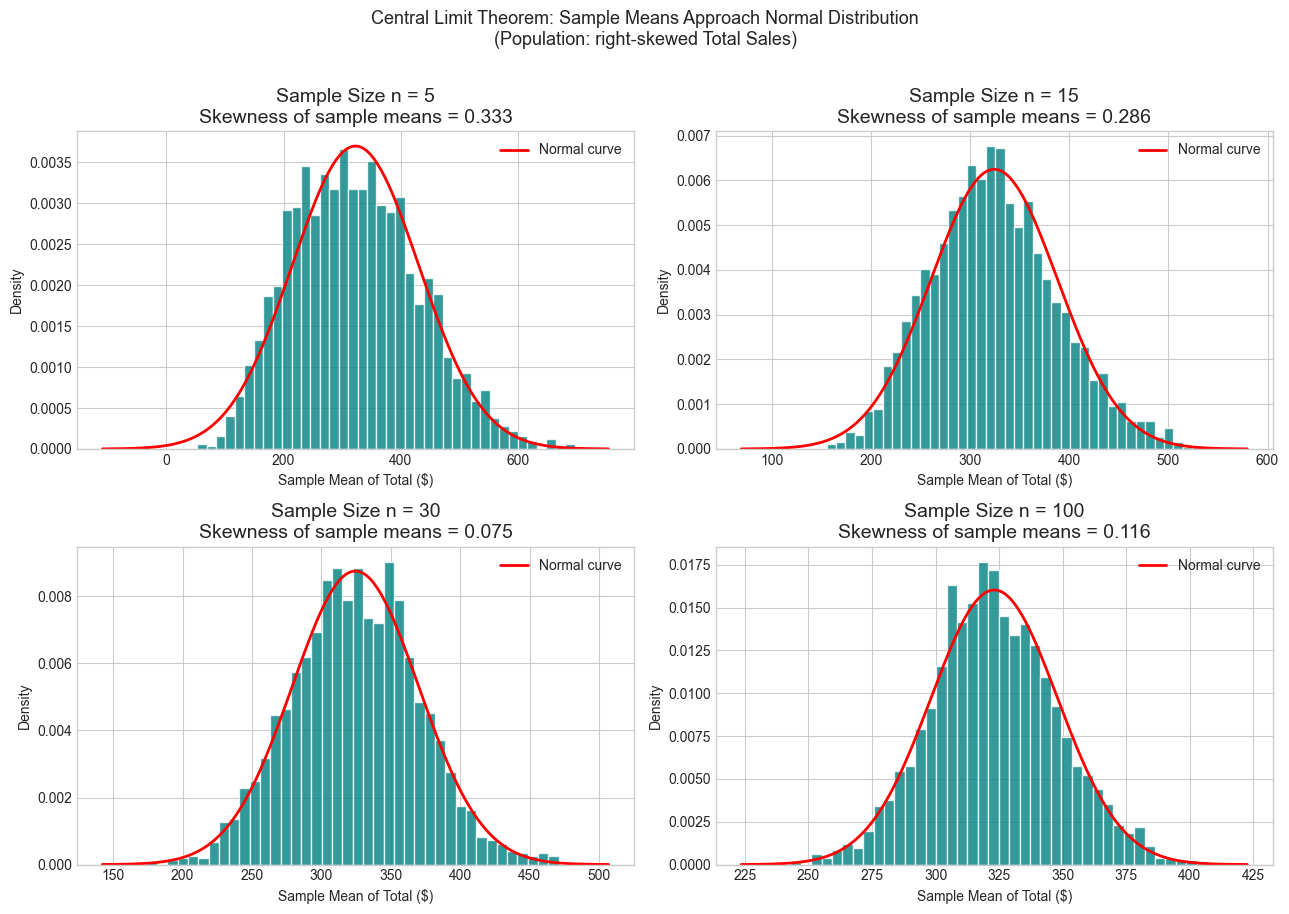

💡 As n increases, the distribution of sample means becomes more symmetric
   (skewness → 0) and bell-shaped, confirming the CLT.


In [14]:
np.random.seed(42)
population = df['Total'].values

sample_sizes = [5, 15, 30, 100]
n_simulations = 2000

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for idx, n in enumerate(sample_sizes):
    # Draw 2000 samples of size n, compute mean of each
    sample_means = [np.mean(np.random.choice(population, n)) for _ in range(n_simulations)]
    sk = skew(sample_means)
    
    axes[idx].hist(sample_means, bins=40, color='teal', edgecolor='white', alpha=0.8, density=True)
    
    # Overlay normal curve
    mu, sigma = np.mean(sample_means), np.std(sample_means)
    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
    axes[idx].plot(x, norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal curve')
    axes[idx].set_title(f'Sample Size n = {n}\nSkewness of sample means = {sk:.3f}')
    axes[idx].set_xlabel('Sample Mean of Total ($)')
    axes[idx].set_ylabel('Density')
    axes[idx].legend()

plt.suptitle('Central Limit Theorem: Sample Means Approach Normal Distribution\n(Population: right-skewed Total Sales)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('💡 As n increases, the distribution of sample means becomes more symmetric')
print('   (skewness → 0) and bell-shaped, confirming the CLT.')

---
# 🎲 Part 3: Probability Rules

Probability quantifies how likely an event is. P(A) is always between 0 and 1, and the sum of all probabilities = 1.

## 3.1 Basic Probability: Empirical Approach

$$P(A) = \frac{\text{Number of times A occurs}}{\text{Total number of outcomes}}$$

In [27]:
n_total = len(df)

# Basic probability examples
p_female    = (df['Gender'] == 'Female').sum() / n_total
p_ewallet   = (df['Payment'] == 'Ewallet').sum() / n_total
p_high_sale = (df['Total'] > 300).sum() / n_total

print('=== Basic (Empirical) Probabilities ===')
print(f'P(Customer is Female)         = {p_female:.4f}  ({p_female*100:.1f}%)')
print(f'P(Payment is Ewallet)         = {p_ewallet:.4f}  ({p_ewallet*100:.1f}%)')
print(f'P(Total > $300)               = {p_high_sale:.4f}  ({p_high_sale*100:.1f}%)')

=== Basic (Empirical) Probabilities ===
P(Customer is Female)         = 0.5010  (50.1%)
P(Payment is Ewallet)         = 0.3450  (34.5%)
P(Total > $300)               = 0.4310  (43.1%)


## 3.2 Addition Rule (OR)

**General Addition Rule:**
$$P(A \cup B) = P(A) + P(B) - P(A \cap B)$$

If A and B are **mutually exclusive** (can't both happen): P(A ∩ B) = 0  
$$P(A \cup B) = P(A) + P(B)$$

**Example:** What's the probability a customer is Female *OR* paid by Ewallet?

In [15]:
is_female  = df['Gender']  == 'Female'
is_ewallet = df['Payment'] == 'Ewallet'

p_A   = is_female.mean()              # P(Female)
p_B   = is_ewallet.mean()             # P(Ewallet)
p_AB  = (is_female & is_ewallet).mean()  # P(Female AND Ewallet)
p_AorB = p_A + p_B - p_AB            # Addition rule

# Verify directly
p_direct = (is_female | is_ewallet).mean()

print('=== Addition Rule: P(Female OR Ewallet) ===')
print(f'  P(Female)            = {p_A:.4f}')
print(f'  P(Ewallet)           = {p_B:.4f}')
print(f'  P(Female AND Ewallet)= {p_AB:.4f}')
print(f'  P(Female OR Ewallet) = {p_A:.4f} + {p_B:.4f} - {p_AB:.4f} = {p_AorB:.4f}')
print(f'  Direct count check   = {p_direct:.4f}  ✅ Match!')

=== Addition Rule: P(Female OR Ewallet) ===
  P(Female)            = 0.5010
  P(Ewallet)           = 0.3450
  P(Female AND Ewallet)= 0.1600
  P(Female OR Ewallet) = 0.5010 + 0.3450 - 0.1600 = 0.6860
  Direct count check   = 0.6860  ✅ Match!


## 3.3 Multiplication Rule & Conditional Probability (AND)

**Conditional Probability:** Probability of A *given* B has already occurred:
$$P(A|B) = \frac{P(A \cap B)}{P(B)}$$

**General Multiplication Rule:**
$$P(A \cap B) = P(A|B) \times P(B)$$

If A and B are **independent** (one doesn't affect the other):
$$P(A \cap B) = P(A) \times P(B)$$

**Example:** Given a customer is Female, what's the probability they paid by Ewallet?

=== Conditional Probability ===
  P(Ewallet | Female)  = 0.3194
  P(Ewallet)           = 0.3450  (unconditional)

=== Independence Test ===
  P(Female) × P(Ewallet) = 0.1728
  P(Female AND Ewallet)  = 0.1600
  Difference = 0.0128 → NOT Independent ❌


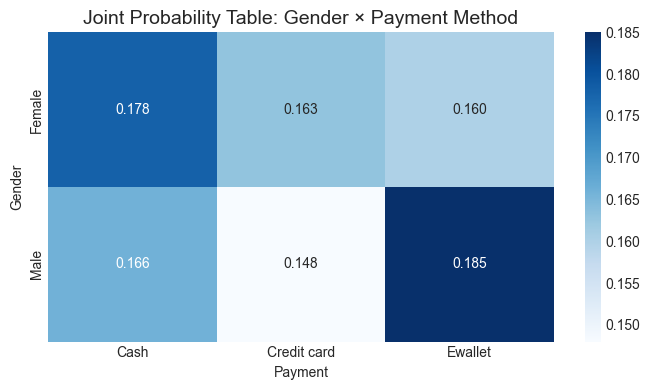

In [16]:
# Conditional probability: P(Ewallet | Female)
female_customers = df[df['Gender'] == 'Female']
p_ewallet_given_female = (female_customers['Payment'] == 'Ewallet').mean()

# Independence check: P(A and B) =? P(A)*P(B)
p_independent = p_A * p_B

print('=== Conditional Probability ===')
print(f'  P(Ewallet | Female)  = {p_ewallet_given_female:.4f}')
print(f'  P(Ewallet)           = {p_B:.4f}  (unconditional)')
print()
print('=== Independence Test ===')
print(f'  P(Female) × P(Ewallet) = {p_independent:.4f}')
print(f'  P(Female AND Ewallet)  = {p_AB:.4f}')
diff = abs(p_independent - p_AB)
print(f'  Difference = {diff:.4f} → {"Approx. Independent ✅" if diff < 0.01 else "NOT Independent ❌"}')

# Heatmap of Gender vs Payment
ct = pd.crosstab(df['Gender'], df['Payment'], normalize='all')
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(ct, annot=True, fmt='.3f', cmap='Blues', ax=ax)
ax.set_title('Joint Probability Table: Gender × Payment Method')
plt.tight_layout()
plt.show()

## 3.4 Bayes' Theorem

Bayes' Theorem lets us **update** our belief about event A after observing evidence B:

$$P(A|B) = \frac{P(B|A) \times P(A)}{P(B)}$$

**Business question:** If a customer paid by Credit Card, what's the probability they're a Member?

In [17]:
# P(A) = P(Member)
p_member = (df['Customer type'] == 'Member').mean()

# P(B) = P(Credit card)
p_cc = (df['Payment'] == 'Credit card').mean()

# P(B|A) = P(Credit card | Member)
members = df[df['Customer type'] == 'Member']
p_cc_given_member = (members['Payment'] == 'Credit card').mean()

# Bayes: P(A|B) = P(B|A) * P(A) / P(B)
p_member_given_cc = (p_cc_given_member * p_member) / p_cc

# Verification
cc_customers = df[df['Payment'] == 'Credit card']
direct = (cc_customers['Customer type'] == 'Member').mean()

print('=== Bayes\' Theorem: P(Member | Credit Card) ===')
print(f'  Prior  P(Member)              = {p_member:.4f}')
print(f'  P(Credit card)                = {p_cc:.4f}')
print(f'  P(Credit card | Member)       = {p_cc_given_member:.4f}')
print(f'  Posterior P(Member | Credit)  = {p_member_given_cc:.4f}  ({p_member_given_cc*100:.1f}%)')
print(f'  Direct count verification     = {direct:.4f}  ✅')

=== Bayes' Theorem: P(Member | Credit Card) ===
  Prior  P(Member)              = 0.5010
  P(Credit card)                = 0.3110
  P(Credit card | Member)       = 0.3433
  Posterior P(Member | Credit)  = 0.5531  (55.3%)
  Direct count verification     = 0.5531  ✅


---
# 📉 Part 4: Probability Distributions

## 4.1 Normal Distribution

The **Normal (Gaussian) distribution** is the most important distribution in statistics. It is:
- Symmetric, bell-shaped
- Fully described by **mean (μ)** and **standard deviation (σ)**
- Models: heights, errors, many natural phenomena

**The Empirical Rule (68-95-99.7):**
- ~68% of data falls within μ ± 1σ
- ~95% of data falls within μ ± 2σ
- ~99.7% of data falls within μ ± 3σ

### Fitting a Normal Distribution to Customer Ratings

Fitted Normal Distribution for Rating:
  μ (mean)  = 6.9727
  σ (std)   = 1.7177

Shapiro-Wilk Test (normality): stat=0.9515, p=0.0000
  →  ❌ Not normal (p ≤ 0.05)


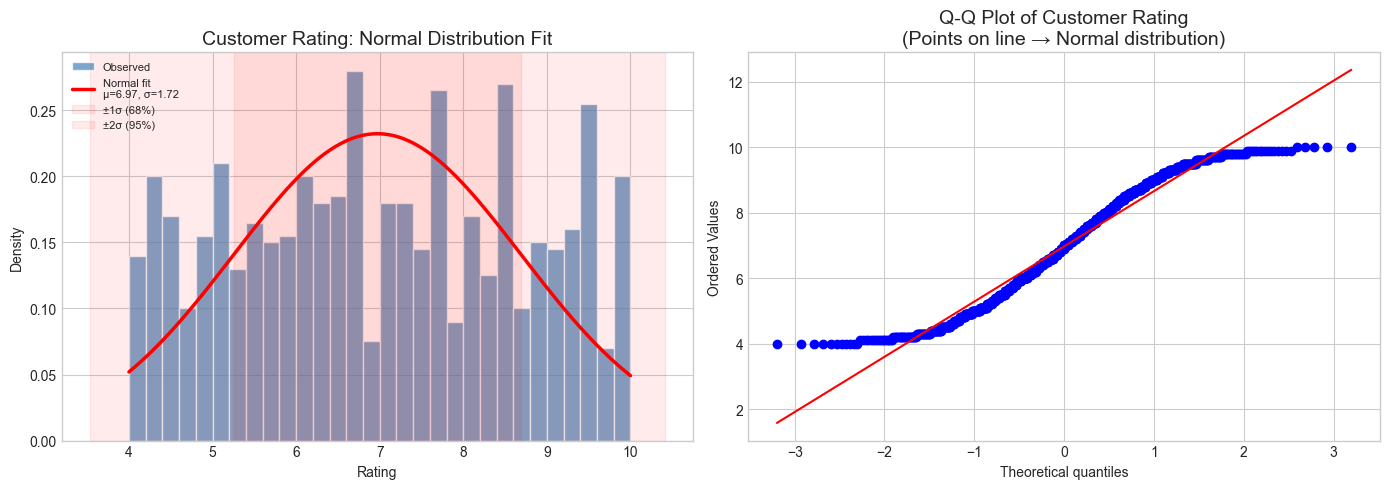

In [18]:
ratings = df['Rating']

# Fit normal distribution parameters
mu_r, sigma_r = norm.fit(ratings)

print(f'Fitted Normal Distribution for Rating:')
print(f'  μ (mean)  = {mu_r:.4f}')
print(f'  σ (std)   = {sigma_r:.4f}')

# Goodness-of-fit test (Shapiro-Wilk on a sample)
sample = ratings.sample(200, random_state=42)
stat, p_value = stats.shapiro(sample)
print(f'\nShapiro-Wilk Test (normality): stat={stat:.4f}, p={p_value:.4f}')
print('  → ', '✅ Looks normal (p > 0.05)' if p_value > 0.05 else '❌ Not normal (p ≤ 0.05)')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram + fitted curve
x = np.linspace(ratings.min(), ratings.max(), 300)
axes[0].hist(ratings, bins=30, density=True, color='steelblue', edgecolor='white', alpha=0.7, label='Observed')
axes[0].plot(x, norm.pdf(x, mu_r, sigma_r), 'r-', lw=2.5, label=f'Normal fit\nμ={mu_r:.2f}, σ={sigma_r:.2f}')
for mult, lbl in [(1,'68%'), (2,'95%')]:
    axes[0].axvspan(mu_r - mult*sigma_r, mu_r + mult*sigma_r, alpha=0.08,
                    color='red', label=f'±{mult}σ ({lbl})')
axes[0].set_title('Customer Rating: Normal Distribution Fit')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# Q-Q Plot
stats.probplot(ratings, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of Customer Rating\n(Points on line → Normal distribution)')

plt.tight_layout()
plt.show()

In [19]:
# Practical probability calculations using Normal distribution

mu_t, sigma_t = norm.fit(df['Total'])

print('=== Normal Distribution Probability Calculations: Total Sales ===')
print(f'  Fitted: μ = ${mu_t:.2f},  σ = ${sigma_t:.2f}')
print()

# P(Total > 500)
p1 = 1 - norm.cdf(500, mu_t, sigma_t)
print(f'P(Transaction > $500)     = {p1:.4f}  ({p1*100:.1f}%)')

# P(Total < 100)
p2 = norm.cdf(100, mu_t, sigma_t)
print(f'P(Transaction < $100)     = {p2:.4f}  ({p2*100:.1f}%)')

# P(200 < Total < 400)
p3 = norm.cdf(400, mu_t, sigma_t) - norm.cdf(200, mu_t, sigma_t)
print(f'P($200 < Transaction < $400) = {p3:.4f}  ({p3*100:.1f}%)')

# Find the 90th percentile
p90 = norm.ppf(0.90, mu_t, sigma_t)
print(f'\n90th Percentile of Total = ${p90:.2f}')
print('  → 90% of transactions are below this amount.')

=== Normal Distribution Probability Calculations: Total Sales ===
  Fitted: μ = $322.97,  σ = $245.76

P(Transaction > $500)     = 0.2357  (23.6%)
P(Transaction < $100)     = 0.1821  (18.2%)
P($200 < Transaction < $400) = 0.3146  (31.5%)

90th Percentile of Total = $637.92
  → 90% of transactions are below this amount.


## 4.2 Binomial Distribution

The **Binomial distribution** models the number of **successes** in *n* independent trials, where each trial has the same probability *p* of success.

- **Parameters:** n (number of trials), p (probability of success)
- **PMF:** $P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$
- **Mean:** μ = np,  **Variance:** σ² = np(1−p)

**Business scenario:** Each customer is either a Member (success) or Normal (failure).  
With `p = P(Member)` from our data, if we randomly sample 20 customers, how many Members do we expect?

**Assumptions:**  
✅ Fixed n (20 customers)  ✅ Two outcomes  ✅ Independent  ✅ Constant p

Binomial(n=20, p=0.5010)
  Expected Members   = n*p  = 10.02
  Variance           = n*p*(1-p) = 5.0000
  Std Dev            = 2.2361

  P(X = 8 Members out of 20) = 0.1192
  P(X = 10 Members out of 20) = 0.1762
  P(X = 12 Members out of 20) = 0.1211
  P(X ≥ 12 Members)           = 0.2546
  P(X ≤ 8 Members)            = 0.2488


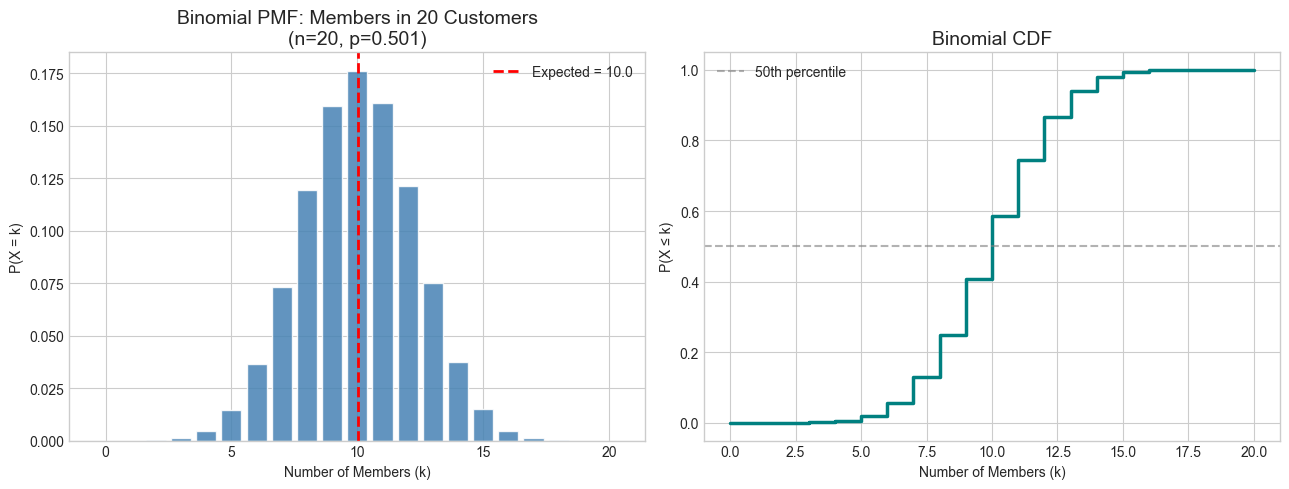

In [20]:
p_success = p_member   # from earlier (proportion of Members)
n_trials  = 20

print(f'Binomial(n={n_trials}, p={p_success:.4f})')
print(f'  Expected Members   = n*p  = {n_trials * p_success:.2f}')
print(f'  Variance           = n*p*(1-p) = {n_trials * p_success * (1-p_success):.4f}')
print(f'  Std Dev            = {np.sqrt(n_trials * p_success * (1-p_success)):.4f}')
print()

# Specific probability calculations
k_vals = [8, 10, 12]
for k in k_vals:
    print(f'  P(X = {k} Members out of 20) = {binom.pmf(k, n_trials, p_success):.4f}')

print(f'  P(X ≥ 12 Members)           = {1 - binom.cdf(11, n_trials, p_success):.4f}')
print(f'  P(X ≤ 8 Members)            = {binom.cdf(8, n_trials, p_success):.4f}')

# Plot PMF
k = np.arange(0, n_trials + 1)
pmf_vals = binom.pmf(k, n_trials, p_success)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# PMF
axes[0].bar(k, pmf_vals, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(n_trials * p_success, color='red', linestyle='--',
                linewidth=2, label=f'Expected = {n_trials*p_success:.1f}')
axes[0].set_title(f'Binomial PMF: Members in 20 Customers\n(n={n_trials}, p={p_success:.3f})')
axes[0].set_xlabel('Number of Members (k)')
axes[0].set_ylabel('P(X = k)')
axes[0].legend()

# CDF
cdf_vals = binom.cdf(k, n_trials, p_success)
axes[1].step(k, cdf_vals, where='post', color='teal', linewidth=2.5)
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='50th percentile')
axes[1].set_title('Binomial CDF')
axes[1].set_xlabel('Number of Members (k)')
axes[1].set_ylabel('P(X ≤ k)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4.3 Poisson Distribution

The **Poisson distribution** models the number of **rare events** occurring in a fixed interval of time or space.

- **Parameter:** λ (lambda) = average rate of occurrence
- **PMF:** $P(X = k) = \frac{e^{-\lambda} \lambda^k}{k!}$
- **Mean = Variance = λ**

**Business scenario:** The dataset covers Jan–Mar 2019 (3 months, ~90 days) with 1,000 transactions.  
Average transactions per day ≈ 1000/90 ≈ **11.1 transactions/day**.

We can model the daily transaction count using Poisson(λ = 11.1).

**Assumptions:**  
✅ Events occur independently  ✅ Average rate (λ) is constant  ✅ Two events can't happen at exactly the same instant

Observed average transactions/day : 11.24
Calculated λ from total/days       : 11.24
Poisson(λ = 11.24): Mean = Variance = 11.24

=== Poisson Probability Calculations ===
P(X = 10 transactions in a day) = 0.1166
P(X = 15 transactions in a day) = 0.0579
P(X > 20 transactions in a day) = 0.0059
P(X < 5 transactions in a day)  = 0.0129


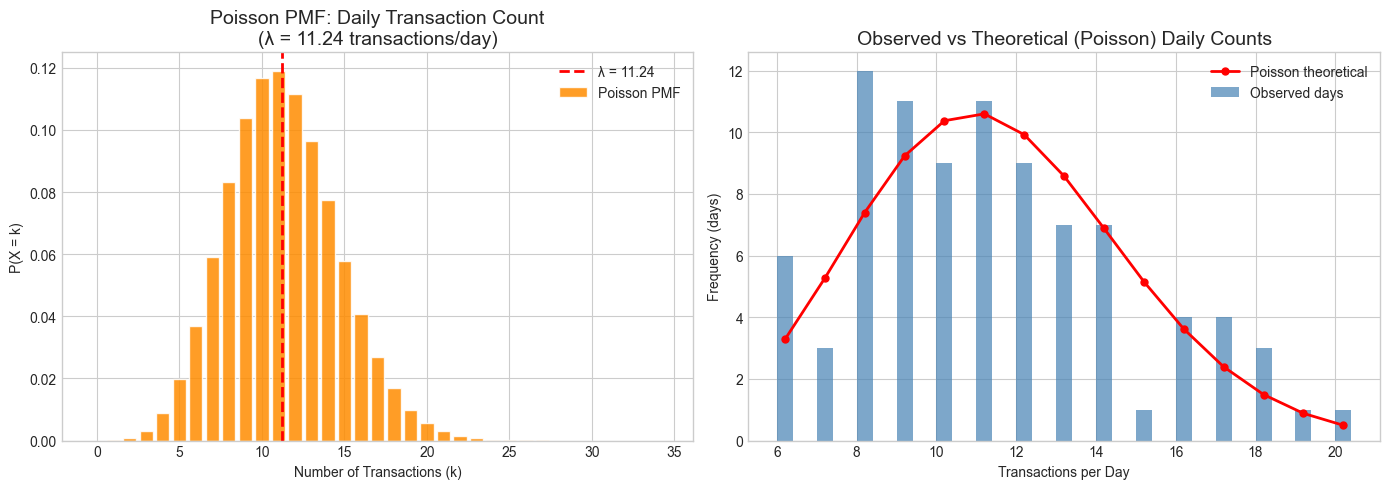

In [21]:
# Compute actual transactions per day from the data
df['Date'] = pd.to_datetime(df['Date'])
daily_counts = df.groupby('Date').size()

lambda_actual = daily_counts.mean()
lambda_theory = len(df) / daily_counts.shape[0]

print(f'Observed average transactions/day : {lambda_actual:.2f}')
print(f'Calculated λ from total/days       : {lambda_theory:.2f}')
print(f'Poisson(λ = {lambda_actual:.2f}): Mean = Variance = {lambda_actual:.2f}')
print()

lam = lambda_actual

print('=== Poisson Probability Calculations ===')
print(f'P(X = 10 transactions in a day) = {poisson.pmf(10, lam):.4f}')
print(f'P(X = 15 transactions in a day) = {poisson.pmf(15, lam):.4f}')
print(f'P(X > 20 transactions in a day) = {1 - poisson.cdf(20, lam):.4f}')
print(f'P(X < 5 transactions in a day)  = {poisson.cdf(4, lam):.4f}')

# Plot
k_range = np.arange(0, 35)
pmf_pois = poisson.pmf(k_range, lam)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PMF
axes[0].bar(k_range, pmf_pois, color='darkorange', edgecolor='white', alpha=0.85, label='Poisson PMF')
axes[0].axvline(lam, color='red', linestyle='--', linewidth=2, label=f'λ = {lam:.2f}')
axes[0].set_title(f'Poisson PMF: Daily Transaction Count\n(λ = {lam:.2f} transactions/day)')
axes[0].set_xlabel('Number of Transactions (k)')
axes[0].set_ylabel('P(X = k)')
axes[0].legend()

# Compare observed daily counts vs Poisson theoretical
obs_range = np.arange(daily_counts.min(), daily_counts.max() + 1)
obs_freq  = daily_counts.value_counts().sort_index()
theo_freq = poisson.pmf(obs_range, lam) * len(daily_counts)

axes[1].bar(obs_freq.index, obs_freq.values, width=0.4, align='edge',
            color='steelblue', alpha=0.7, label='Observed days')
axes[1].plot(obs_range + 0.2, theo_freq, 'ro-', linewidth=2, markersize=5, label='Poisson theoretical')
axes[1].set_title('Observed vs Theoretical (Poisson) Daily Counts')
axes[1].set_xlabel('Transactions per Day')
axes[1].set_ylabel('Frequency (days)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
# 📊 Part 5: Distribution Comparison Summary

Let's visualise all three distributions side by side for reference.

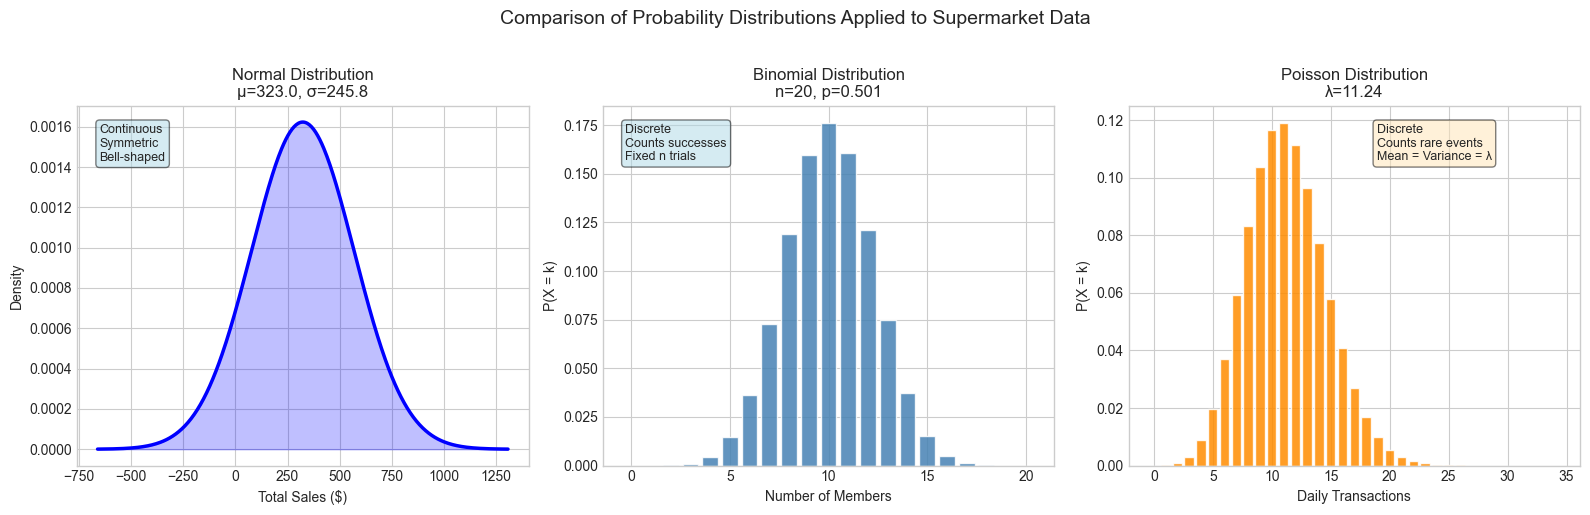

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Normal
x_n = np.linspace(mu_t - 4*sigma_t, mu_t + 4*sigma_t, 400)
axes[0].plot(x_n, norm.pdf(x_n, mu_t, sigma_t), 'b-', lw=2.5)
axes[0].fill_between(x_n, norm.pdf(x_n, mu_t, sigma_t), alpha=0.25, color='blue')
axes[0].set_title(f'Normal Distribution\nμ={mu_t:.1f}, σ={sigma_t:.1f}', fontsize=12)
axes[0].set_xlabel('Total Sales ($)')
axes[0].set_ylabel('Density')
axes[0].text(0.05, 0.95, 'Continuous\nSymmetric\nBell-shaped',
             transform=axes[0].transAxes, va='top', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# Binomial
k_b = np.arange(0, n_trials + 1)
axes[1].bar(k_b, binom.pmf(k_b, n_trials, p_success),
            color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_title(f'Binomial Distribution\nn={n_trials}, p={p_success:.3f}', fontsize=12)
axes[1].set_xlabel('Number of Members')
axes[1].set_ylabel('P(X = k)')
axes[1].text(0.05, 0.95, 'Discrete\nCounts successes\nFixed n trials',
             transform=axes[1].transAxes, va='top', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# Poisson
k_p = np.arange(0, 35)
axes[2].bar(k_p, poisson.pmf(k_p, lam),
            color='darkorange', edgecolor='white', alpha=0.85)
axes[2].set_title(f'Poisson Distribution\nλ={lam:.2f}', fontsize=12)
axes[2].set_xlabel('Daily Transactions')
axes[2].set_ylabel('P(X = k)')
axes[2].text(0.55, 0.95, 'Discrete\nCounts rare events\nMean = Variance = λ',
             transform=axes[2].transAxes, va='top', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='moccasin', alpha=0.5))

plt.suptitle('Comparison of Probability Distributions Applied to Supermarket Data', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
# 📝 Summary

| Concept | Formula / Key Idea | Applied to |
|---------|-------------------|------------|
| **Mean** | Sum / n | Avg transaction = $322.97 |
| **Median** | Middle value | Less affected by big sales |
| **Mode** | Most frequent value | Common transaction amount |
| **Variance** | Avg squared deviation | Spread of sales |
| **Std Dev** | √Variance | Typical deviation from mean |
| **Skewness** | Asymmetry of distribution | Total sales: slightly right-skewed |
| **Kurtosis** | Tail heaviness | Ratings: near-normal (platykurtic) |
| **Addition Rule** | P(A∪B) = P(A)+P(B)−P(A∩B) | P(Female OR Ewallet) |
| **Multiplication Rule** | P(A∩B) = P(A\|B)×P(B) | P(Female AND Ewallet) |
| **Bayes' Theorem** | P(A\|B) = P(B\|A)P(A)/P(B) | P(Member \| Credit card) |
| **Normal Dist.** | Bell curve, μ & σ | Transaction totals, ratings |
| **Binomial Dist.** | Successes in n trials | Members in 20 customers |
| **Poisson Dist.** | Rare events per interval | Daily transactions |

---

> **Next steps:** Explore hypothesis testing (t-test, chi-square), confidence intervals, and regression analysis to build on these foundations.